<a href="https://colab.research.google.com/github/soumya0422/Advanced-DS-and-ML/blob/main/Advanced_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Call:
lm(formula = weight ~ height)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.5059 -1.3910  0.2515  0.9794  2.0382 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -28.90893   11.14159  -2.595   0.0319 *  
height        0.62867    0.07657   8.211 3.62e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.413 on 8 degrees of freedom
Multiple R-squared:  0.8939,	Adjusted R-squared:  0.8807 
F-statistic: 67.42 on 1 and 8 DF,  p-value: 3.619e-05


[1] "Predicted weight for height 145: 62.25"


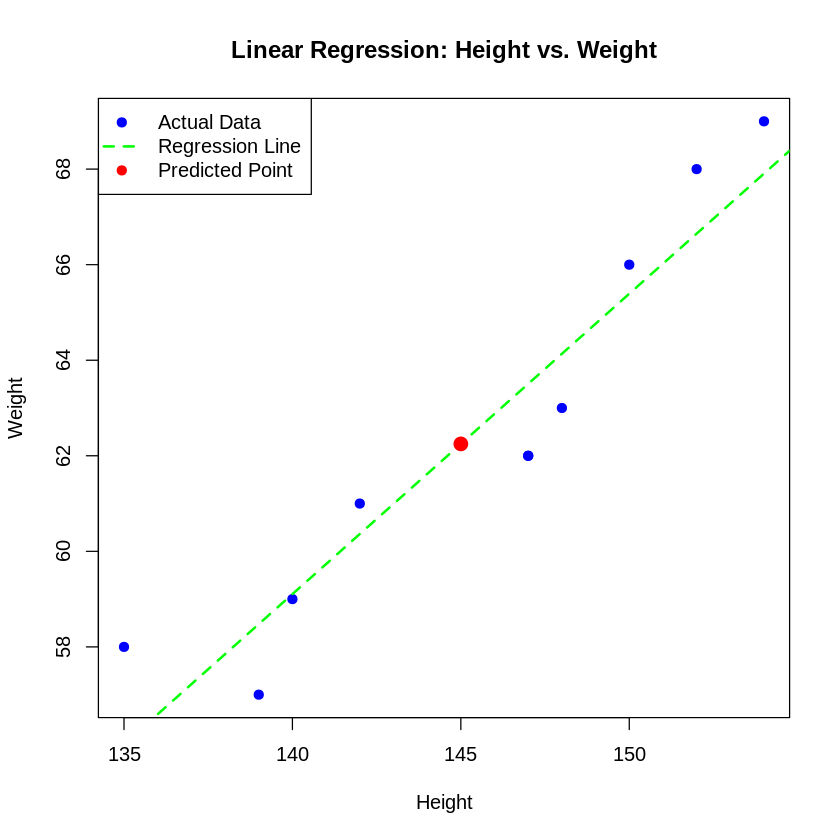

In [1]:
height <- c(140, 142, 150, 147, 139, 152, 154, 135, 148, 147)
weight <- c(59, 61, 66, 62, 57, 68, 69, 58, 63, 62)

# Create linear regression model
model <- lm(weight ~ height)

# Print model summary
summary(model)

# Predict weight for a given height (example: 145)
predicted_height <- data.frame(height = 145)
predicted_weight <- predict(model, predicted_height)
print(paste("Predicted weight for height 145:", round(predicted_weight, 2)))

# Plot data points
plot(height, weight, col="blue", pch=19, main="Linear Regression: Height vs. Weight", xlab="Height", ylab="Weight")

# Add regression line
abline(model, col="green", lwd=2, lty=2)

# Highlight predicted point
points(145, predicted_weight, col="red", pch=19, cex=1.5)
legend("topleft", legend=c("Actual Data", "Regression Line", "Predicted Point"),
       col=c("blue", "green", "red"), pch=c(19, NA, 19), lty=c(NA, 2, NA), lwd=c(NA, 2, NA))

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Disease ~ Height + Weight, family = binomial, data = mice_data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   -1901.04 3504656.61  -0.001    1.000
Height          -10.84   41588.66   0.000    1.000
Weight           56.00   86849.19   0.001    0.999

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.3460e+01  on 9  degrees of freedom
Residual deviance: 9.2176e-10  on 7  degrees of freedom
AIC: 6

Number of Fisher Scoring iterations: 25


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Failed to fit group 2.
Caused by error:
! y values must be 0 <= y <= 1”


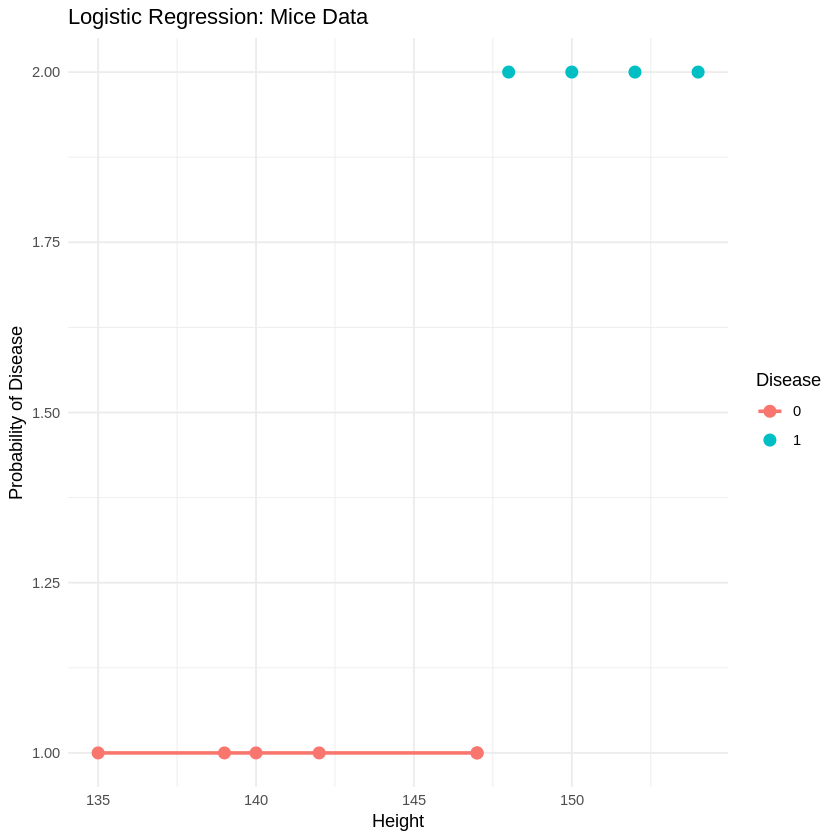

In [2]:

library(ggplot2)

# Create the dataset manually
mice_data <- data.frame(
  Height = c(140, 142, 150, 147, 139, 152, 154, 135, 148, 147),
  Weight = c(59, 61, 66, 62, 57, 68, 69, 58, 63, 62),
  Disease = c(0, 0, 1, 0, 0, 1, 1, 0, 1, 0)  # Example binary classification (0 = No Disease, 1 = Disease)
)

# Convert Disease to a factor
mice_data$Disease <- factor(mice_data$Disease, levels = c(0, 1))

# Train the logistic regression model
model <- glm(Disease ~ Height + Weight, data = mice_data, family = binomial)

# Summarize the model
summary(model)

# Generate a sequence of values for Height and Weight to predict probabilities
new_data <- expand.grid(
  Height = seq(min(mice_data$Height), max(mice_data$Height), length.out = 100),
  Weight = seq(min(mice_data$Weight), max(mice_data$Weight), length.out = 100)
)

# Predict probabilities for the grid
new_data$Predicted_Prob <- predict(model, newdata = new_data, type = "response")

# Plot the data and logistic regression results
ggplot(mice_data, aes(x = Height, y = as.numeric(Disease), color = Disease)) +
  geom_point(size = 3) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), se = FALSE) +
  labs(title = "Logistic Regression: Mice Data", x = "Height", y = "Probability of Disease") +
  theme_minimal()


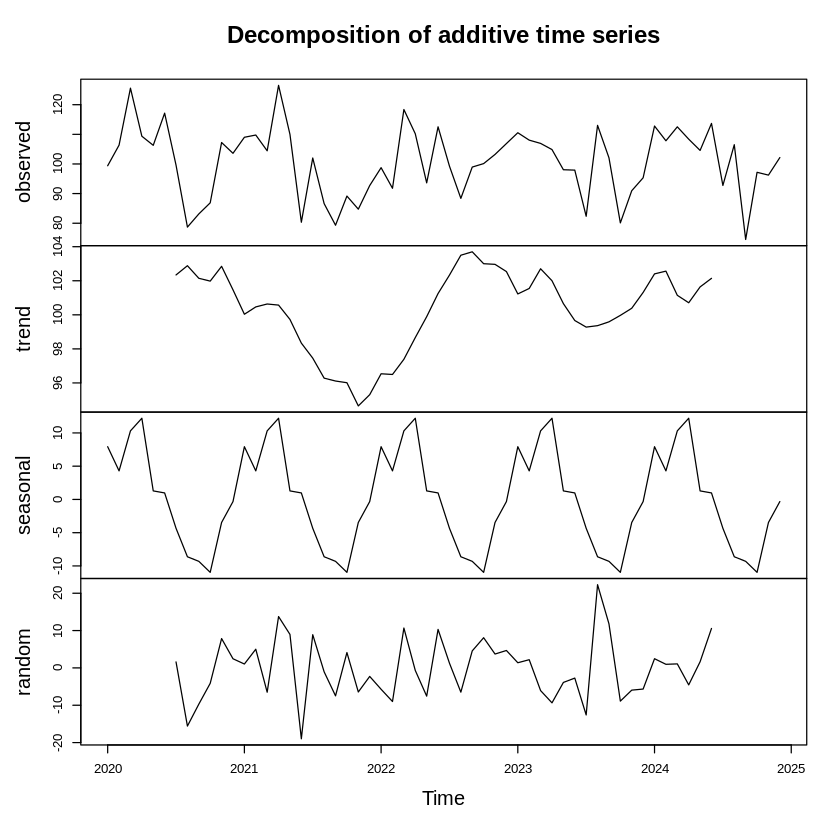

In [3]:

library(ggplot2)

# Generate example time series data (monthly data for 5 years)
set.seed(123)  # For reproducibility
time_series_data <- ts(rnorm(60, mean = 100, sd = 10) + sin(1:60 * 2 * pi / 12) * 10,
                       frequency = 12, start = c(2020, 1))

# Decompose the time series data
decomposed_data <- decompose(time_series_data)

# Plot the decomposed components
plot(decomposed_data)


In [7]:
install.packages("caTools")
library(datasets)
library(caTools)

# Load the iris dataset
data(iris)

# Create a subset with only two species (e.g., 'setosa' and 'versicolor')
iris_subset <- subset(iris, Species %in% c("setosa", "versicolor"))

# Convert Species to a binary factor (0 and 1)
iris_subset$Species <- factor(iris_subset$Species, levels = c("setosa", "versicolor"))

# Split data into training and testing sets (80% train, 20% test)
set.seed(123)
split <- sample.split(iris_subset$Species, SplitRatio = 0.8)
train_data <- subset(iris_subset, split == TRUE)
test_data <- subset(iris_subset, split == FALSE)

# Train the logistic regression model
model <- glm(Species ~ Sepal.Length + Sepal.Width + Petal.Length + Petal.Width,
             data = train_data, family = binomial)

# Summarize the model
summary(model)

# Make predictions on test data
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to class labels
predicted_classes <- ifelse(predictions > 0.5, "versicolor", "setosa")

# Confusion matrix to evaluate model performance
table(Predicted = predicted_classes, Actual = test_data$Species)

# Calculate accuracy
accuracy <- mean(predicted_classes == test_data$Species)
print(paste("Model Accuracy:", round(accuracy, 4)))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Species ~ Sepal.Length + Sepal.Width + Petal.Length + 
    Petal.Width, family = binomial, data = train_data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)
(Intercept)       2.441 719536.470       0        1
Sepal.Length     -8.839 228602.119       0        1
Sepal.Width      -7.529 101423.669       0        1
Petal.Length     18.606 161584.079       0        1
Petal.Width      25.537 235297.693       0        1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.1090e+02  on 79  degrees of freedom
Residual deviance: 1.0367e-09  on 75  degrees of freedom
AIC: 10

Number of Fisher Scoring iterations: 25


            Actual
Predicted    setosa versicolor
  setosa         10          0
  versicolor      0         10

[1] "Model Accuracy: 1"


In [8]:
# Load necessary library
library(dplyr)

# Function to detect and remove outliers using IQR method
remove_outliers_iqr <- function(data, column_name) {
  Q1 <- quantile(data[[column_name]], 0.25, na.rm = TRUE)
  Q3 <- quantile(data[[column_name]], 0.75, na.rm = TRUE)
  IQR_value <- Q3 - Q1

  lower_bound <- Q1 - 1.5 * IQR_value
  upper_bound <- Q3 + 1.5 * IQR_value

  filtered_data <- data %>% filter(data[[column_name]] >= lower_bound & data[[column_name]] <= upper_bound)
  return(filtered_data)
}

# Function to detect and remove outliers using Z-score method
remove_outliers_zscore <- function(data, column_name, threshold = 3) {
  mean_value <- mean(data[[column_name]], na.rm = TRUE)
  sd_value <- sd(data[[column_name]], na.rm = TRUE)

  z_scores <- (data[[column_name]] - mean_value) / sd_value

  filtered_data <- data %>% filter(abs(z_scores) <= threshold)
  return(filtered_data)
}

# Example usage with a sample dataset
data <- data.frame(Value = c(10, 12, 15, 14, 500, 13, 12, 14, 9, 8, 1000))

# Remove outliers using IQR method
cleaned_data_iqr <- remove_outliers_iqr(data, "Value")
print("Data after removing outliers using IQR method:")
print(cleaned_data_iqr)

# Remove outliers using Z-score method
cleaned_data_zscore <- remove_outliers_zscore(data, "Value")
print("Data after removing outliers using Z-score method:")
print(cleaned_data_zscore)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Data after removing outliers using IQR method:"
  Value
1    10
2    12
3    15
4    14
5    13
6    12
7    14
8     9
9     8
[1] "Data after removing outliers using Z-score method:"
   Value
1     10
2     12
3     15
4     14
5    500
6     13
7     12
8     14
9      9
10     8
11  1000


In [ ]:
# Load necessary library
library(dplyr)

# Function to clean invalid values from a dataset
clean_data <- function(df, replace_with = 0) {
  df <- df %>%
    mutate(across(everything(), ~ ifelse(is.na(.), replace_with, .))) %>%  # Replace NA
    mutate(across(everything(), ~ ifelse(is.nan(.), replace_with, .))) %>%  # Replace NaN
    mutate(across(everything(), ~ ifelse(is.infinite(.), replace_with, .))) %>%  # Replace Inf
    mutate(across(where(is.numeric), ~ ifelse(. < 0, replace_with, .)))  # Replace negative values

  return(df)
}

# Example usage with a sample dataset
data <- data.frame(
  A = c(1,2,NA, 4, Inf),
  B = c(NaN, 5, 6,-3,8),
  C = c(-3, 2,7, 8,9)
)

print("Original Data:")
print(data)

# Clean the data, replacing invalid values with 0
cleaned_data <- clean_data(data, replace_with = 0)

print("Cleaned Data:")
print(cleaned_data)



[1] "Original Data:"
    A   B  C
1   1 NaN -3
2   2   5  2
3  NA   6  7
4   4  -3  8
5 Inf   8  9
[1] "Cleaned Data:"
  A B C
1 1 0 0
2 2 5 2
3 0 6 7
4 4 0 8
5 0 8 9


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



Holt-Winters exponential smoothing without trend and without seasonal component.

Call:
HoltWinters(x = time_series_data, beta = FALSE, gamma = FALSE)

Smoothing parameters:
 alpha: 0.07145747
 beta : FALSE
 gamma: FALSE

Coefficients:
      [,1]
a 101.2237


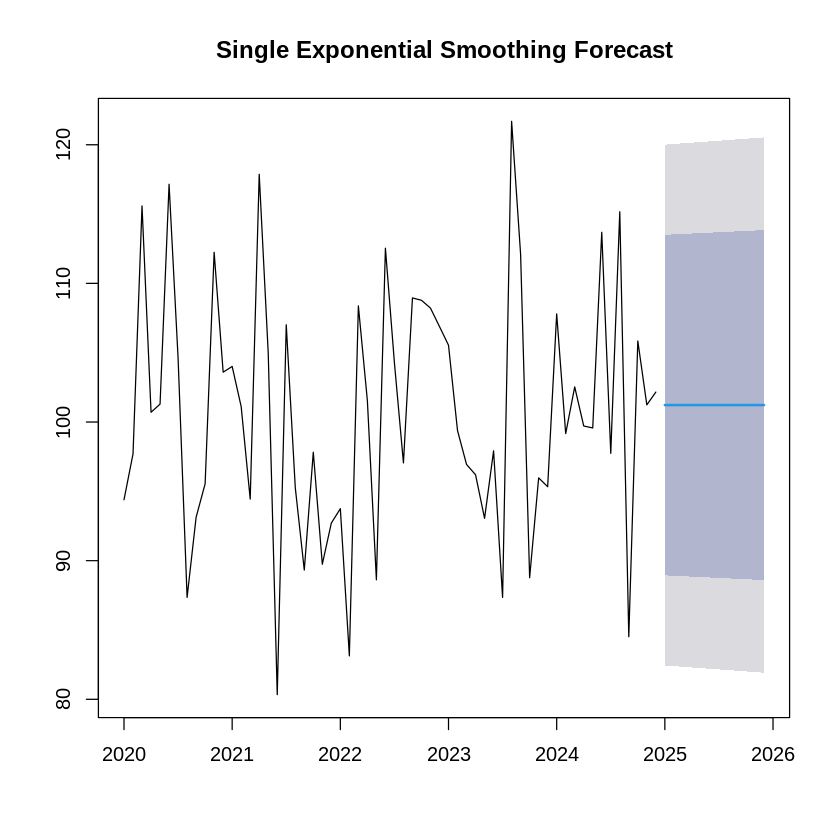

In [11]:

library(forecast)

# Generate example time series data (monthly data for 5 years)
set.seed(123)  # For reproducibility
time_series_data <- ts(rnorm(60, mean = 100, sd = 10), frequency = 12, start = c(2020, 1))

# Apply Single Exponential Smoothing (SES)
ses_model <- HoltWinters(time_series_data, beta = FALSE, gamma = FALSE)

# Print model details
print(ses_model)

# Forecast for next 12 months
forecast_values <- forecast(ses_model, h = 12)

# Plot the forecast
plot(forecast_values, main="Single Exponential Smoothing Forecast")


In [10]:
install.packages("forecast")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



  Sepal.Length Sepal.Width Petal.Length Petal.Width
1     5.006000    3.428000     1.462000    0.246000
2     5.901613    2.748387     4.393548    1.433871
3     6.850000    3.073684     5.742105    2.071053


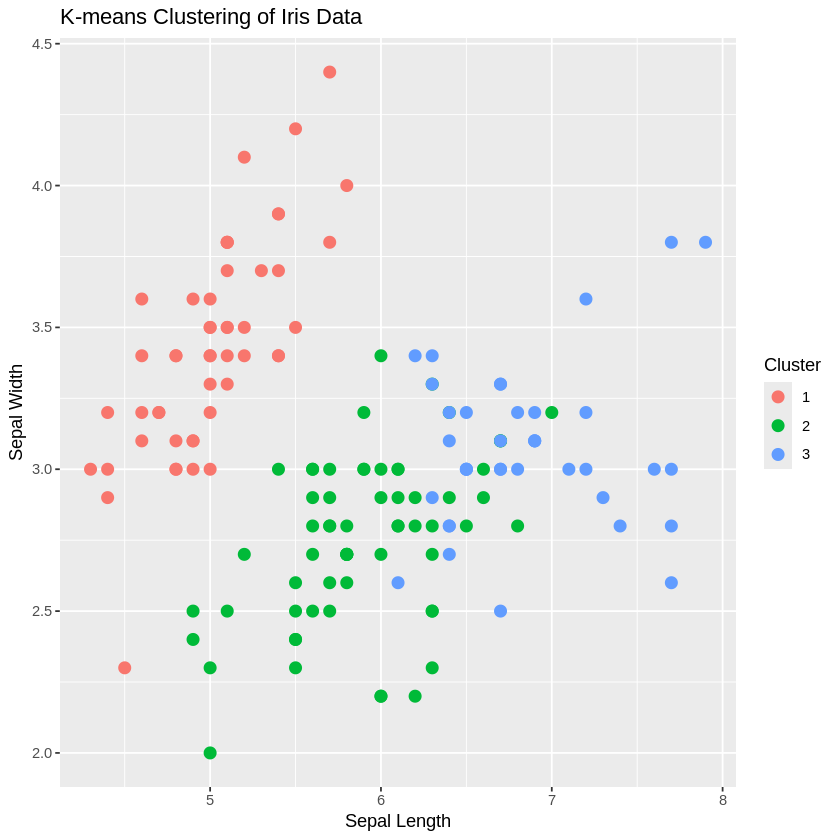

In [12]:

install.packages("ggplot2")  # For visualization

# Load necessary library
library(ggplot2)

# K-means clustering implementation
perform_kmeans <- function(data, num_clusters) {
  set.seed(123)  # For reproducibility
  kmeans_result <- kmeans(data, centers = num_clusters, nstart = 25)

  # Add cluster labels to the data
  data$Cluster <- as.factor(kmeans_result$cluster)

  return(list(model = kmeans_result, clustered_data = data))
}

# Example usage
data(iris)
iris_data <- iris[, 1:4]  # Selecting only numerical attributes
num_clusters <- 3  # Number of clusters

# Perform K-means clustering
kmeans_result <- perform_kmeans(iris_data, num_clusters)

# Print cluster centers
print(kmeans_result$model$centers)

# Visualizing the clusters (using first two principal components)
iris_data$Cluster <- kmeans_result$clustered_data$Cluster
ggplot(iris_data, aes(x = iris_data[,1], y = iris_data[,2], color = Cluster)) +
  geom_point(size = 3) +
  labs(title = "K-means Clustering of Iris Data", x = "Sepal Length", y = "Sepal Width")


In [13]:
install.packages("rpart")
library(rpart)

# Function to calculate entropy
entropy <- function(target) {
  prob <- table(target) / length(target)
  -sum(prob * log2(prob))
}

# Function to calculate information gain
info_gain <- function(data, feature, target) {
  total_entropy <- entropy(data[[target]])

  feature_values <- unique(data[[feature]])
  weighted_entropy <- 0

  for (val in feature_values) {
    subset <- data[data[[feature]] == val, ]
    weighted_entropy <- weighted_entropy + (nrow(subset) / nrow(data)) * entropy(subset[[target]])
  }

  return (total_entropy - weighted_entropy)
}

# ID3 algorithm implementation
id3 <- function(data, target, features) {
  unique_classes <- unique(data[[target]])

  if (length(unique_classes) == 1) {
    return(unique_classes[1])  # If only one class remains, return it
  }

  if (length(features) == 0) {
    return(names(which.max(table(data[[target]]))))  # Majority class
  }

  # Select the best feature using information gain
  gains <- sapply(features, function(f) info_gain(data, f, target))
  best_feature <- features[which.max(gains)]

  # Create the tree node
  tree <- list()
  tree[[best_feature]] <- list()

  for (val in unique(data[[best_feature]])) {
    subset <- data[data[[best_feature]] == val, ]

    if (nrow(subset) == 0) {
      tree[[best_feature]][[val]] <- names(which.max(table(data[[target]])))
    } else {
      tree[[best_feature]][[val]] <- id3(subset, target, setdiff(features, best_feature))
    }
  }

  return(tree)
}

# Example usage
data(iris)
iris$Species <- as.character(iris$Species)  # Convert factor to character
features <- colnames(iris)[1:4]  # Feature names
decision_tree <- id3(iris, "Species", features)
print(decision_tree)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



$Petal.Length
$Petal.Length[[1]]
[1] "setosa"

$Petal.Length[[2]]
NULL

$Petal.Length[[3]]
[1] "versicolor"

$Petal.Length[[4]]
[1] "versicolor"

$Petal.Length[[5]]
[1] "virginica"

$Petal.Length[[6]]
[1] "virginica"




In [ ]:
# Install necessary package
install.packages("cluster")  # For hierarchical clustering functions
library(cluster)

# Function to compute Euclidean distance
euc_dist <- function(p1, p2) {
  sqrt(sum((p1 - p2) ^ 2))
}

# CURE clustering algorithm implementation
cure_clustering <- function(data, num_clusters, num_representative_points = 5, shrink_factor = 0.2) {
  set.seed(123)  # For reproducibility

  # Step 1: Start with each point as a separate cluster
  clusters <- lapply(1:nrow(data), function(i) list(points = data[i, ], repr = data[i, ]))

  # Function to compute distance between clusters (minimum pairwise distance)
  cluster_distance <- function(c1, c2) {
    min(sapply(1:nrow(c1$repr), function(i) {
      sapply(1:nrow(c2$repr), function(j) euc_dist(c1$repr[i, ], c2$repr[j, ]))
    }))
  }

  # Step 2: Merge clusters until desired number is reached
  while (length(clusters) > num_clusters) {
    dist_matrix <- outer(1:length(clusters), 1:length(clusters), Vectorize(function(i, j) {
      if (i < j) cluster_distance(clusters[[i]], clusters[[j]]) else Inf
    }))

    # Find closest pair of clusters
    min_indices <- which(dist_matrix == min(dist_matrix), arr.ind = TRUE)
    cluster_1 <- min_indices[1, 1]
    cluster_2 <- min_indices[1, 2]

    # Merge clusters
    new_cluster_points <- rbind(clusters[[cluster_1]]$points, clusters[[cluster_2]]$points)

    # Select representative points
    new_repr_points <- new_cluster_points[sample(1:nrow(new_cluster_points), num_representative_points, replace = TRUE), ]

    # Shrink representative points towards cluster centroid
    centroid <- colMeans(new_repr_points)
    new_repr_points <- centroid + shrink_factor * (new_repr_points - centroid)

    # Create new cluster
    new_cluster <- list(points = new_cluster_points, repr = new_repr_points)

    # Remove old clusters and add new one
    clusters <- clusters[-c(cluster_1, cluster_2)]
    clusters <- append(clusters, list(new_cluster))
  }

  return(clusters)
}

# Example usage
data(iris)
iris_data <- iris[, 1:4]  # Selecting only numerical attributes
num_clusters <- 3  # Number of clusters

# Perform CURE clustering
cure_result <- cure_clustering(iris_data, num_clusters)

# Print cluster details
print(length(cure_result))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] 3


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] Sepal.Length Sepal.Width  Petal.Length Petal.Width  Species     
<0 rows> (or 0-length row.names)
[1] 150


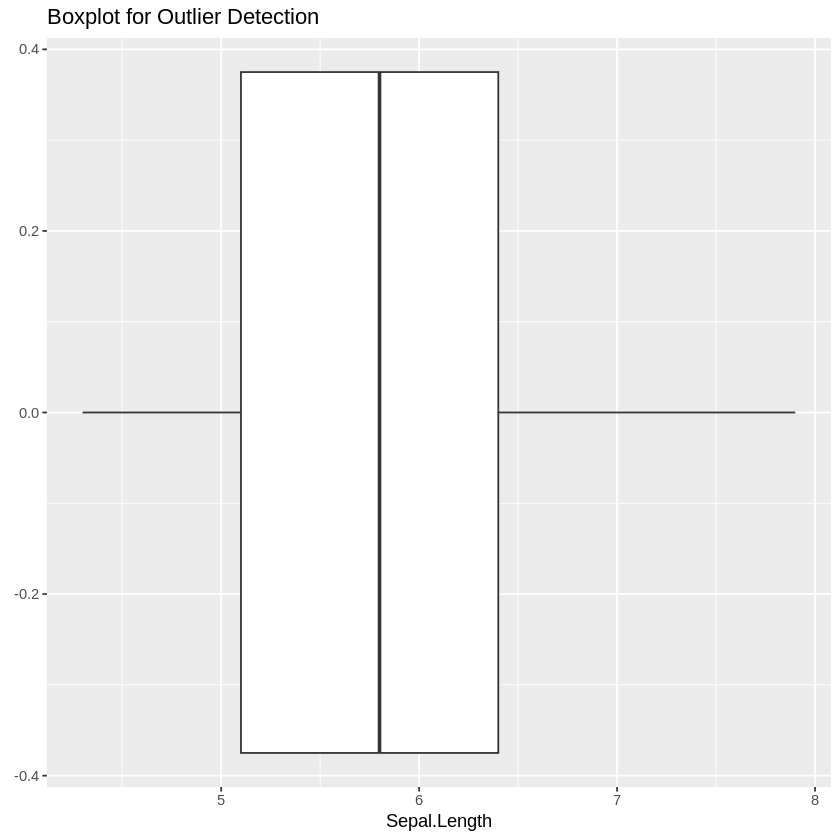

In [14]:

install.packages("ggplot2")  # For visualization
install.packages("dplyr")    # For data manipulation

# Load libraries
library(ggplot2)
library(dplyr)

# Function to detect outliers using IQR method
detect_outliers <- function(data, column) {
  Q1 <- quantile(data[[column]], 0.25)
  Q3 <- quantile(data[[column]], 0.75)
  IQR_value <- Q3 - Q1

  lower_bound <- Q1 - 1.5 * IQR_value
  upper_bound <- Q3 + 1.5 * IQR_value

  return(data %>% filter(data[[column]] < lower_bound | data[[column]] > upper_bound))
}

# Function to remove outliers using IQR method
remove_outliers <- function(data, column) {
  Q1 <- quantile(data[[column]], 0.25)
  Q3 <- quantile(data[[column]], 0.75)
  IQR_value <- Q3 - Q1

  lower_bound <- Q1 - 1.5 * IQR_value
  upper_bound <- Q3 + 1.5 * IQR_value

  return(data %>% filter(data[[column]] >= lower_bound & data[[column]] <= upper_bound))
}

# Example usage
data(iris)
outliers <- detect_outliers(iris, "Sepal.Length")
cleaned_data <- remove_outliers(iris, "Sepal.Length")

# Print outliers and cleaned data
print(outliers)
print(nrow(cleaned_data))

# Visualizing outliers
ggplot(iris, aes(x = Sepal.Length)) +
  geom_boxplot(outlier.colour = "red", outlier.shape = 16, outlier.size = 2) +
  labs(title = "Boxplot for Outlier Detection")


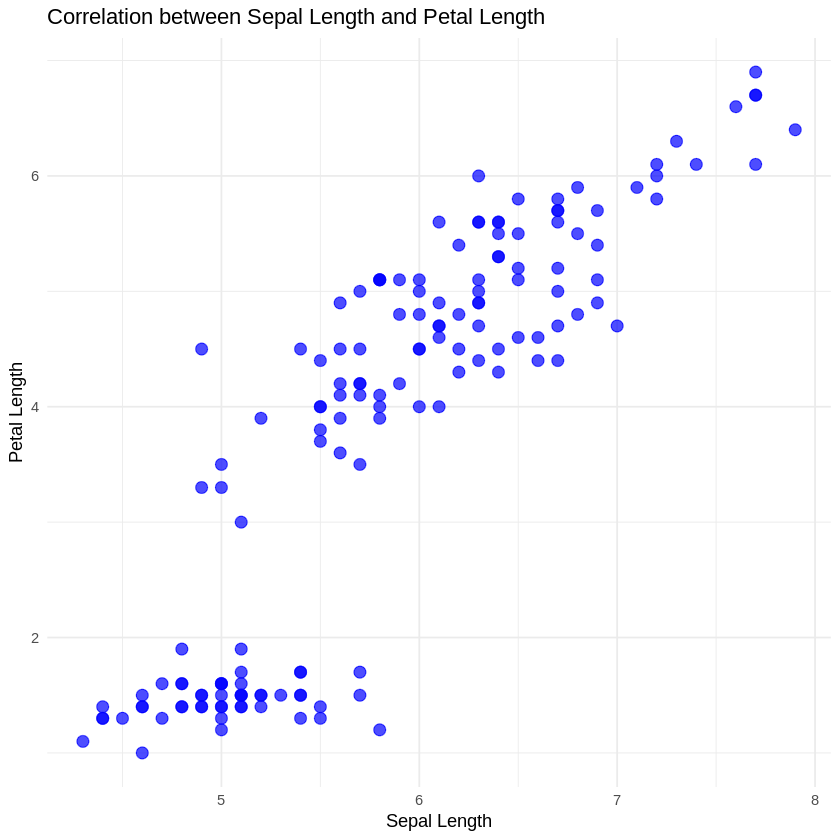

In [16]:

library(ggplot2)

# Load the iris dataset
data(iris)

# Create a scatter plot
ggplot(iris, aes(x = Sepal.Length, y = Petal.Length)) +
  geom_point(color = "blue", size = 3, alpha = 0.7) +  # Add scatter points
  labs(title = "Correlation between Sepal Length and Petal Length",
       x = "Sepal Length",
       y = "Petal Length") +
  theme_minimal()  # Apply minimal theme for better visualization


In [26]:
# ---------------- Utility Functions ----------------

# Calculate entropy of target
entropy <- function(target) {
  prob <- table(target) / length(target)
  -sum(prob * log2(prob))
}

# Calculate gain ratio of a feature
gain_ratio <- function(data, feature, target) {
  total_entropy <- entropy(data[[target]])
  values <- unique(data[[feature]])
  weighted_entropy <- 0
  split_info <- 0

  for (val in values) {
    subset <- data[data[[feature]] == val, ]
    prob <- nrow(subset) / nrow(data)
    weighted_entropy <- weighted_entropy + prob * entropy(subset[[target]])
    if (prob > 0) {
      split_info <- split_info - prob * log2(prob)
    }
  }

  info_gain <- total_entropy - weighted_entropy
  if (split_info == 0 || is.nan(split_info)) return(NA)
  return(info_gain / split_info)
}

# ---------------- Recursive C4.5 Algorithm ----------------

c45 <- function(data, target, features) {
  # Base case: only one class left
  if (length(unique(data[[target]])) == 1) {
    return(unique(data[[target]])[1])
  }

  # Base case: no features left
  if (length(features) == 0) {
    return(names(which.max(table(data[[target]]))))
  }

  # Calculate gain ratios
  gains <- sapply(features, function(f) gain_ratio(data, f, target))
  names(gains) <- features
  gains <- gains[!is.na(gains)]

  # Check if we have valid gains
  if (length(gains) == 0) {
    return(names(which.max(table(data[[target]]))))
  }

  # Choose best feature
  best_feature <- names(which.max(gains))
  tree <- list()
  tree[[best_feature]] <- list()

  # Recurse on each value of the best feature
  for (val in unique(data[[best_feature]])) {
    subset <- data[data[[best_feature]] == val, ]
    val_str <- as.character(val)
    if (nrow(subset) == 0) {
      tree[[best_feature]][[val_str]] <- names(which.max(table(data[[target]])))
    } else {
      remaining_features <- setdiff(features, best_feature)
      tree[[best_feature]][[val_str]] <- c45(subset, target, remaining_features)
    }
  }

  return(tree)
}

# ---------------- Example: Iris Dataset ----------------

data(iris)
iris$Species <- as.character(iris$Species)  # Convert factor to character
features <- colnames(iris)[1:4]             # Use all 4 features
decision_tree <- c45(iris, "Species", features)

print(decision_tree)


$Petal.Width
$Petal.Width$`0.2`
[1] "setosa"

$Petal.Width$`0.4`
[1] "setosa"

$Petal.Width$`0.3`
[1] "setosa"

$Petal.Width$`0.1`
[1] "setosa"

$Petal.Width$`0.5`
[1] "setosa"

$Petal.Width$`0.6`
[1] "setosa"

$Petal.Width$`1.4`
$Petal.Width$`1.4`$Petal.Length
$Petal.Width$`1.4`$Petal.Length$`4.7`
[1] "versicolor"

$Petal.Width$`1.4`$Petal.Length$`3.9`
[1] "versicolor"

$Petal.Width$`1.4`$Petal.Length$`4.4`
[1] "versicolor"

$Petal.Width$`1.4`$Petal.Length$`4.8`
[1] "versicolor"

$Petal.Width$`1.4`$Petal.Length$`4.6`
[1] "versicolor"

$Petal.Width$`1.4`$Petal.Length$`5.6`
[1] "virginica"



$Petal.Width$`1.5`
$Petal.Width$`1.5`$Petal.Length
$Petal.Width$`1.5`$Petal.Length$`4.5`
[1] "versicolor"

$Petal.Width$`1.5`$Petal.Length$`4.9`
[1] "versicolor"

$Petal.Width$`1.5`$Petal.Length$`4.6`
[1] "versicolor"

$Petal.Width$`1.5`$Petal.Length$`4.2`
[1] "versicolor"

$Petal.Width$`1.5`$Petal.Length$`4.7`
[1] "versicolor"

$Petal.Width$`1.5`$Petal.Length$`5`
[1] "virginica"

$Petal.Width$`1.5